# Week2

### info
```
Shreyas Nayak
240911006
Week2 
dataset : pokemon_data.xlsc
```

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/shreyas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_excel("pokemon_data.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 55 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   national_number     898 non-null    int64  
 1   gen                 898 non-null    object 
 2   english_name        898 non-null    object 
 3   japanese_name       898 non-null    object 
 4   primary_type        898 non-null    object 
 5   secondary_type      469 non-null    object 
 6   classification      898 non-null    object 
 7   percent_male        776 non-null    object 
 8   percent_female      776 non-null    object 
 9   height_m            898 non-null    float64
 10  weight_kg           898 non-null    float64
 11  capture_rate        898 non-null    object 
 12  base_egg_steps      898 non-null    int64  
 13  hp                  898 non-null    int64  
 14  attack              898 non-null    int64  
 15  defense             898 non-null    int64  
 16  sp_attac

In [3]:
df.shape

(898, 55)

In [4]:
df.isnull().sum()

national_number         0
gen                     0
english_name            0
japanese_name           0
primary_type            0
secondary_type        429
classification          0
percent_male          122
percent_female        122
height_m                0
weight_kg               0
capture_rate            0
base_egg_steps          0
hp                      0
attack                  0
defense                 0
sp_attack               0
sp_defense              0
speed                   0
abilities_0             0
abilities_1           403
abilities_2           895
abilities_hidden      135
against_normal          0
against_fire            0
against_water           0
against_electric        0
against_grass           0
against_ice             0
against_fighting        0
against_poison          0
against_ground          0
against_flying          0
against_psychic         0
against_bug             0
against_rock            0
against_ghost           0
against_dragon          0
against_dark

In [5]:
# Assuming that pokemon does not have the next stage like raichu after that nothing 
df.fillna(0,inplace = True)
df.isnull().sum()

national_number       0
gen                   0
english_name          0
japanese_name         0
primary_type          0
secondary_type        0
classification        0
percent_male          0
percent_female        0
height_m              0
weight_kg             0
capture_rate          0
base_egg_steps        0
hp                    0
attack                0
defense               0
sp_attack             0
sp_defense            0
speed                 0
abilities_0           0
abilities_1           0
abilities_2           0
abilities_hidden      0
against_normal        0
against_fire          0
against_water         0
against_electric      0
against_grass         0
against_ice           0
against_fighting      0
against_poison        0
against_ground        0
against_flying        0
against_psychic       0
against_bug           0
against_rock          0
against_ghost         0
against_dragon        0
against_dark          0
against_steel         0
against_fairy         0
is_sublegendary 

## Question 1
### Detect outliers in weight_kg and height_m. Are there any abnormally large or small Pokémon?

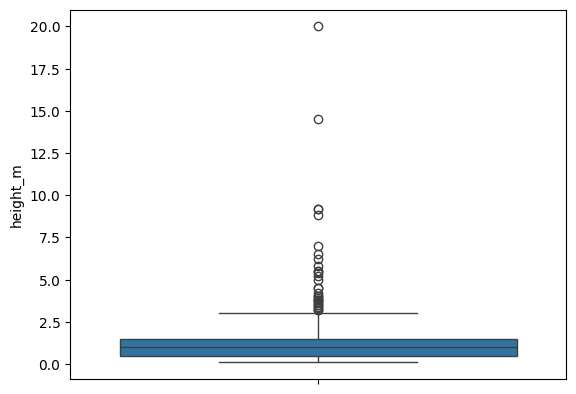

In [6]:
sns.boxplot(y = df["height_m"])
plt.show()

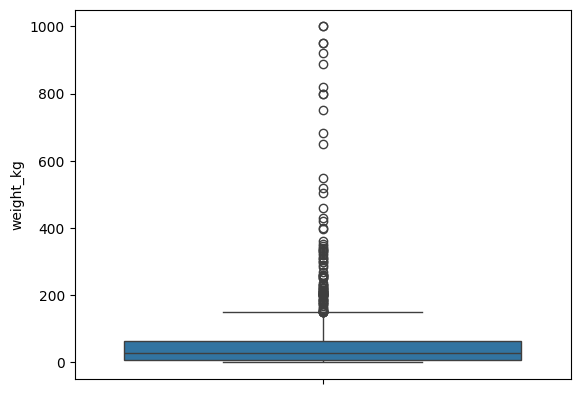

In [7]:
sns.boxplot(y = df["weight_kg"])
plt.show()

Yes there are many height and weight outliers in the data <br>
but i feel that theese outliers matter because there are pokemons with soo much weight compared to others like Hoopa unbound

## Question 2
### Remove outliers from hp, then find the average hp by generation. Does the trend change after outlier removal?

In [8]:
df["hp"].describe()

count    898.000000
mean      69.031180
std       26.213707
min        1.000000
25%       50.000000
50%       65.000000
75%       80.000000
max      255.000000
Name: hp, dtype: float64

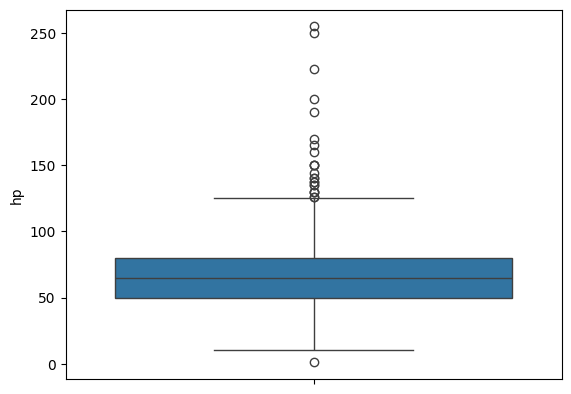

before removing outliers, hp mean : 
 gen
I       64.211921
II      70.980000
III     65.666667
IV      73.102804
V       70.314103
VI      68.916667
VII     71.011364
VIII    71.112360
Name: hp, dtype: float64


In [9]:
sns.boxplot(y = df["hp"])
plt.show()

print("before removing outliers, hp mean : \n" , df.groupby("gen")["hp"].mean())

In [10]:
Q1 = df['hp'].quantile(0.25)  
Q3 = df['hp'].quantile(0.75)  

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['hp'] >= lower) &(df['hp'] <= upper)]

print("after removing outliers, hp mean : \n" , df.groupby("gen")["hp"].mean())

after removing outliers, hp mean : 
 gen
I       60.863014
II      67.887755
III     63.615385
IV      71.028846
V       69.703226
VI      67.285714
VII     66.869048
VIII    68.839080
Name: hp, dtype: float64


## Question 3
### Use Z-score to find unusual values in attack. What are the top 5 outliers?

In [11]:
mean_attack = df['attack'].mean()
std_attack = df['attack'].std()

df['attack_zscore'] = (df['attack'] - mean_attack) / std_attack

x = df.loc[df['attack_zscore'].nlargest(5).index]
print(x[['english_name', 'attack', 'attack_zscore']])


    english_name  attack  attack_zscore
797      Kartana     181       3.577481
408    Rampardos     165       3.031603
485    Regigigas     160       2.861016
382      Groudon     150       2.519843
383     Rayquaza     150       2.519843


## Question 4
### How does the average attack vary across different primary_types?

In [12]:
df.groupby('primary_type')['attack'].mean()

primary_type
bug         65.932432
dark        82.500000
dragon      98.766667
electric    73.897959
fairy       59.850000
fighting    99.371429
fire        83.741379
flying      71.571429
ghost       68.068966
grass       72.767442
ground      92.657143
ice         73.071429
normal      73.893204
poison      72.676471
psychic     61.854545
rock        87.120000
steel       86.689655
water       70.949153
Name: attack, dtype: float64

from this we can see that attack of fighting witll be high est and lowest for fairy

## Question 5
### Find the average HP of Pokémon from each generation.

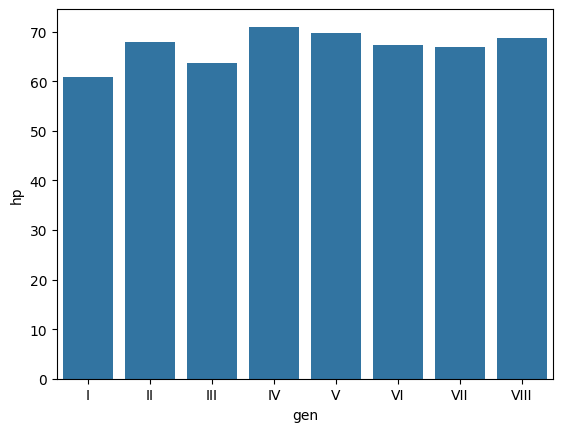

In [13]:
df.groupby("gen")["hp"].mean()

sns.barplot(df.groupby("gen")["hp"].mean())
plt.show()

## Question 6
### How many Pokémon have a secondary type?

In [14]:
(df['secondary_type'] != 0).sum()

459

## Question 7
### Which secondary types appear most frequently with Water as the primary type?

In [15]:
water = df[(df['primary_type'] == 'water')]

water.groupby("secondary_type").size()

secondary_type
0           63
bug          2
dark         4
dragon       3
electric     2
fairy        4
fighting     2
flying       7
ghost        2
grass        3
ground       9
ice          3
poison       3
psychic      5
rock         5
steel        1
dtype: int64

the highest sec type with water as primary is ground

## Question 8
### Compare the average total stat of Pokémon who are Legendary, Sub-Legendary, and Mythical.What insights do you find?

In [16]:
status_list = []

for i in range(len(df)):
    if df.iloc[i]['is_mythical'] == 1:
        status_list.append("Mythical")
    elif df.iloc[i]['is_legendary'] == 1:
        status_list.append("Legendary")
    elif df.iloc[i]['is_sublegendary'] == 1:
        status_list.append("Sub-Legendary")
    else:
        status_list.append("Normal")

df['status'] = status_list

df.groupby('status')[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].mean()


,hp,attack,defense,sp_attack,sp_defense,speed
status,,,,,,
Legendary,95.266667,109.000000,102.933333,114.666667,106.266667,87.866667
Mythical,84.800000,101.300000,93.350000,110.950000,97.150000,96.450000
Normal,64.767588,73.478643,69.522613,65.791457,66.945980,63.350503
Sub-Legendary,84.558140,102.279070,97.302326,98.790698,94.906977,92.604651


The legendary overall has really better stats compared to other types whereas its slower compared to others.<br>
it makes sense cuz dialga palkia and giratina cant run cuz they are fatt.

## Question 9
### Create a heatmap of correlations between all stat columns. What pairs are most correlated?

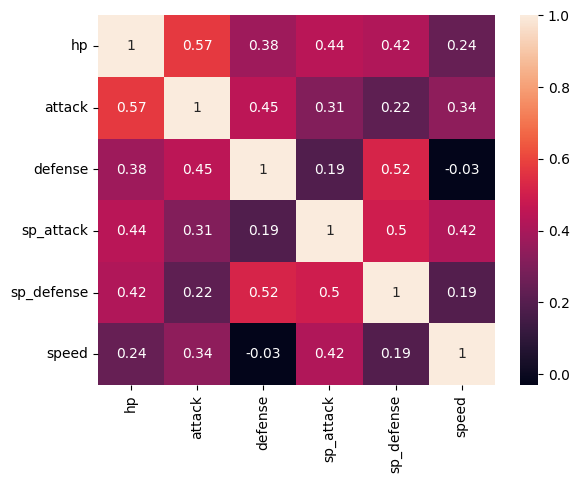

In [17]:
corr = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].corr()

sns.heatmap(corr, annot=True)
plt.show()

## Question 10
### Create a histogram showing the distribution of speed values.

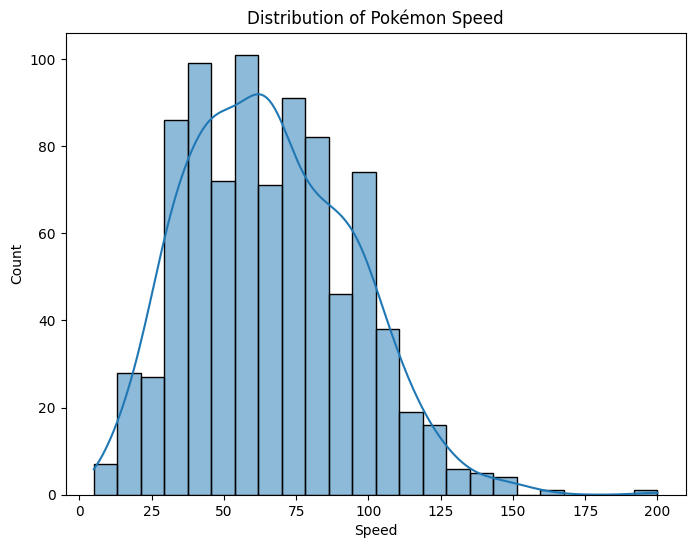

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(df['speed'], kde=True, edgecolor='black')
plt.title("Distribution of Pokémon Speed")
plt.xlabel("Speed")
plt.ylabel("Count")
plt.show()

## Question 11
### Plot the average total stat (hp + other stats) by generation.

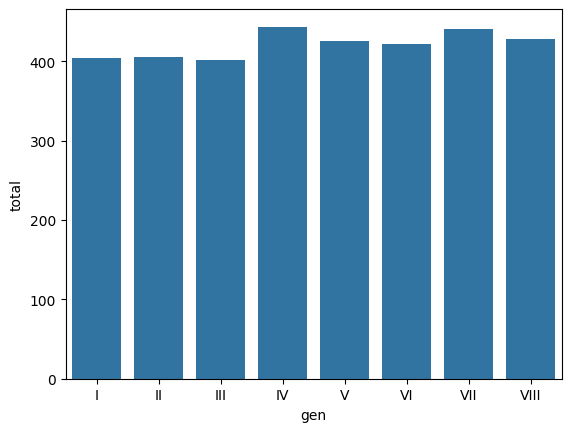

In [19]:
df['total'] = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].sum(axis=1)

sns.barplot(x = "gen" , y = "total" , data = df.groupby('gen')['total'].mean().reset_index())
plt.show()

## Question 12
### Visualize the number of Pokémon who can Gigantamax vs those who can't.

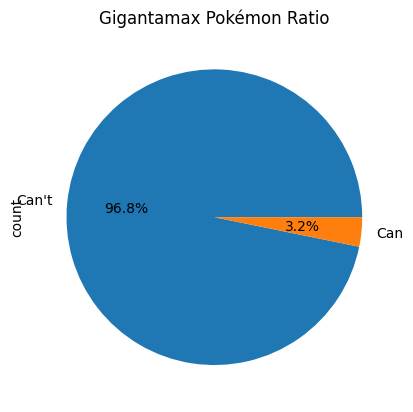

In [20]:
gigantamax_status = []

for i in df.index:
    if df.loc[i, 'gigantamax'] == 0:
        gigantamax_status.append(0)
    else:
        gigantamax_status.append(1)

df['can_gigantamax'] = gigantamax_status

counts = df['can_gigantamax'].value_counts().sort_index()

counts.plot.pie(
    autopct='%1.1f%%',
    labels=["Can't", "Can"],
)

plt.title("Gigantamax Pokémon Ratio")
plt.show()


Thank youu

### BoNus Question

## Question 13
### Compare the Eeveelutions 

In [21]:
stats = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']

df_eevee  = df[df['evochain_0'] == 'Eevee'][['english_name'] + stats]

df_eevee

,english_name,hp,attack,defense,sp_attack,sp_defense,speed
132,Eevee,55,55,50,45,65,55
134,Jolteon,65,65,60,110,95,130
135,Flareon,65,130,60,95,110,65
195,Espeon,65,65,60,130,95,110
196,Umbreon,95,65,110,60,130,65
469,Leafeon,65,110,130,60,65,95
470,Glaceon,65,60,110,130,95,65
699,Sylveon,95,65,65,110,130,60


<Axes: >

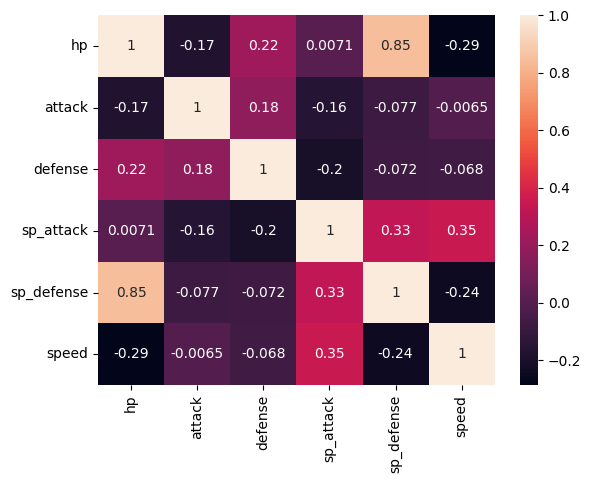

In [22]:
corr = df[df['evochain_0'] == 'Eevee'][stats].corr()

sns.heatmap(corr , annot = True)

## Question 14
### Season 2 Episode 4 comparison

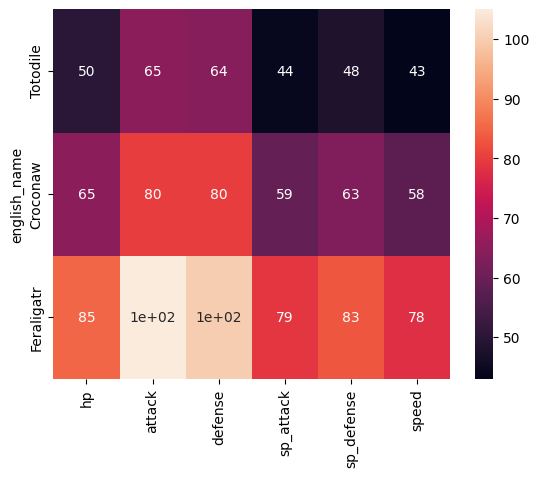

In [23]:
# fight about totodile so seeing Totodile's Stats (btw to Totodile > Chicorita)

totodile_line = df[df['evochain_0'] == 'Totodile']

totodile_stats = totodile_line[['english_name', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].set_index('english_name')

sns.heatmap(totodile_stats, annot=True)
plt.show()


<Axes: >

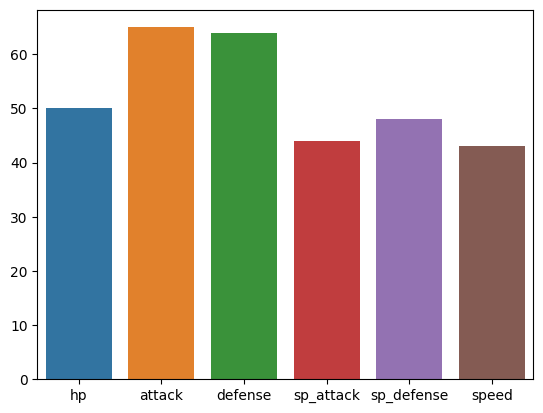

In [24]:
sns.barplot(df[df['english_name'] == 'Totodile'][stats])

## Question 15
### Who would win a Pokethon?

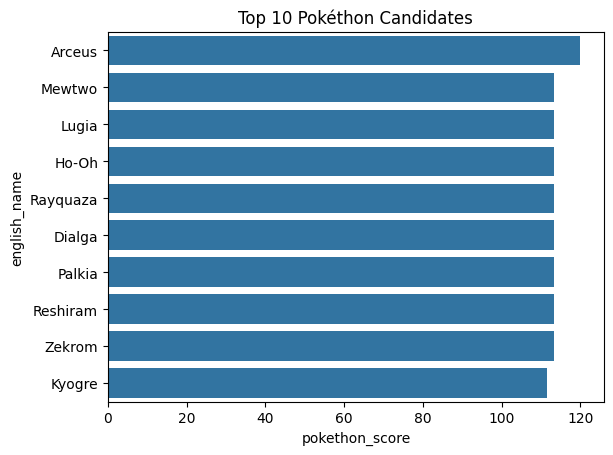

In [25]:
# if pokethon is about the pokemon battle

df['pokethon_score'] = df[['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].mean(axis=1)

top_10 = df[['english_name', 'pokethon_score']].nlargest(10 , 'pokethon_score')

sns.barplot(data=top_10, x='pokethon_score', y='english_name')
plt.title("Top 10 Pokéthon Candidates")
plt.show()



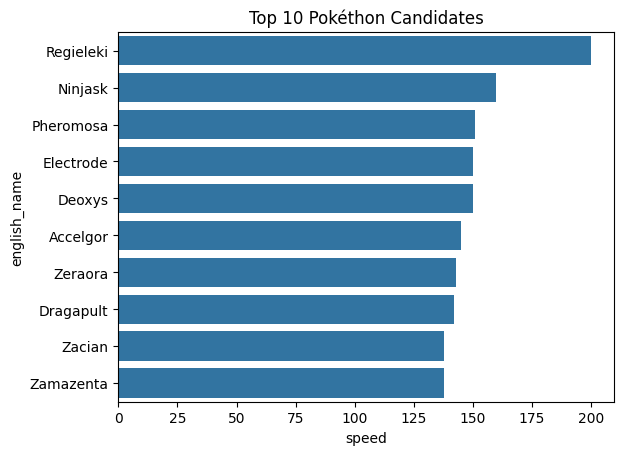

In [26]:
# if pokethon means pokemon marathon

top = df.nlargest(10 , "speed")
sns.barplot(data=top, x='speed', y='english_name')
plt.title("Top 10 Pokéthon Candidates")
plt.show()

# Thank yOU